In [1]:
import torch
import matplotlib.pyplot as plt

from src.diffeomorphisms.vector.starflow import StarFlowVectorDiffeomorphism

from src.distributions.starflows.recentered import RecenteredStarFlowDistribution
from src.distributions.stars.ellipsoid.multimodal import MultiModalEllipsoidStarDistribution

from src.manifolds.euclidean.vector.pullback.standard import StandardPullbackVectorEuclidean

## Construct Data ##

/Users/wdiepeveen/Documents/Postdoc/projects/6 - Lyme Geometry/Lyme-Geometry/.venv/lib/python3.13/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


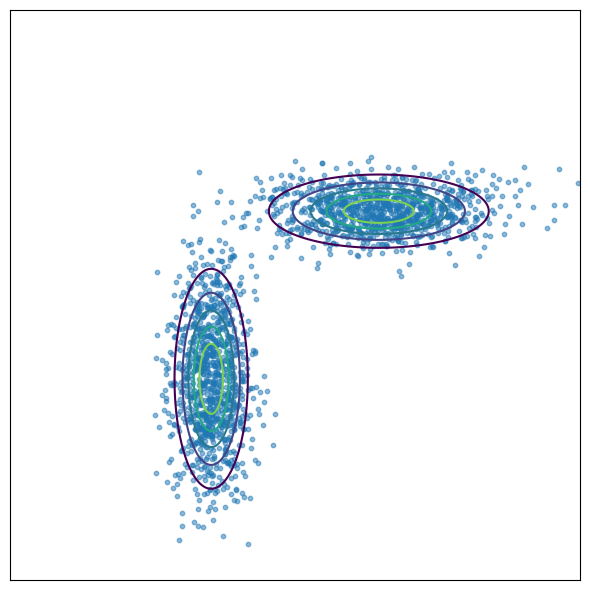

In [2]:
# construct bimodal GMM
offset = 5.
lambda_max = 3.
lambda_min = 1/lambda_max
mu_1 = torch.tensor([-offset, 0.])
mu_2 = torch.tensor([0., offset])
cov_1 = torch.diag(torch.tensor([lambda_min, lambda_max]))
cov_2 = torch.diag(torch.tensor([lambda_max, lambda_min]))

dist_1 = torch.distributions.MultivariateNormal(mu_1, cov_1)
dist_2 = torch.distributions.MultivariateNormal(mu_2, cov_2)

samples_1 = dist_1.sample((1000,))
samples_2 = dist_2.sample((1000,))
samples = torch.cat([samples_1, samples_2], dim=0)

xx = torch.linspace(-6.0 - offset, 6.0, 500)
yy = torch.linspace(-6.0, 6.0 + offset, 500)
x_grid, y_grid = torch.meshgrid(xx, yy)

xy_grid = torch.zeros((*x_grid.shape,2))
xy_grid[:,:,0] = x_grid
xy_grid[:,:,1] = y_grid

log_probs_1 = dist_1.log_prob(xy_grid.reshape(-1,2)).reshape(x_grid.shape)
log_probs_2 = dist_2.log_prob(xy_grid.reshape(-1,2)).reshape(x_grid.shape)

density = torch.exp(log_probs_1) + torch.exp(log_probs_2)
levels = torch.linspace(density.min(), density.max(), 7)  # Adjust the number of levels as needed        # Retrieve the automatically generated levels
new_levels = levels[1:]         # Remove the first (smallest) level

plt.figure(figsize=(6,6))
plt.contour(x_grid, y_grid, density, levels=new_levels)
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, s=10)
plt.xlim(-6.0 - offset, 6.0)
plt.ylim(-6.0, 6.0 + offset)
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.show()

## Find Clusters ##

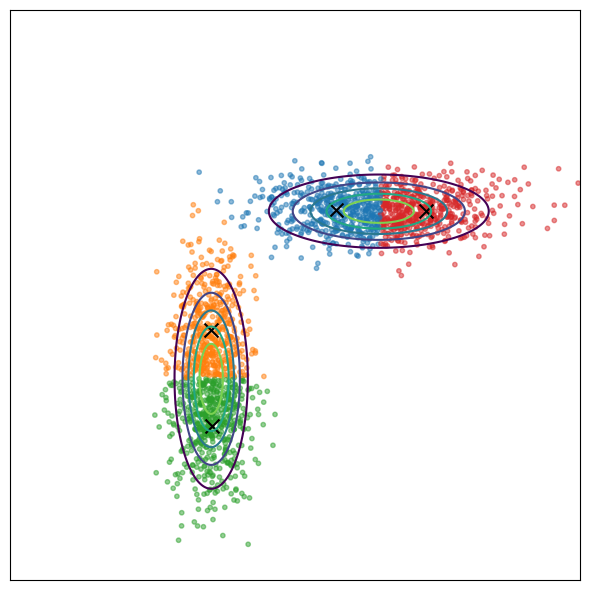

In [3]:
# kmeans clustering
from sklearn.cluster import KMeans

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(samples)
cluster_centers = torch.from_numpy(kmeans.cluster_centers_)
cluster_labels = torch.from_numpy(kmeans.labels_)

plt.figure(figsize=(6,6))
plt.contour(x_grid, y_grid, density, levels=new_levels)
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=plt.get_cmap('tab10')(cluster_labels), s=10)
plt.scatter(cluster_centers[:,0], cluster_centers[:,1], c='black', marker='x', s=100)
plt.xlim(-6.0 - offset, 6.0)
plt.ylim(-6.0, 6.0 + offset)
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.show()

## Find Cluster Covariances ##

In [4]:
# construct covariance matrix per cluster
cluster_covariances = []
cluster_sizes = []
for i in range(n_clusters):
    cluster_samples = samples[cluster_labels == i]
    cluster_sizes.append(cluster_samples.shape[0])
    cov = torch.einsum('ni,nj->ij', cluster_samples - cluster_centers[i], cluster_samples - cluster_centers[i]) / (cluster_sizes[i] - 1)
    cluster_covariances.append(cov)

# regularize covariances if necessary TODO
inv_cluster_covariances = torch.cat([torch.linalg.inv(cov)[None] for cov in cluster_covariances], dim=0)
print(inv_cluster_covariances.shape)

torch.Size([4, 2, 2])


## Find Root ##

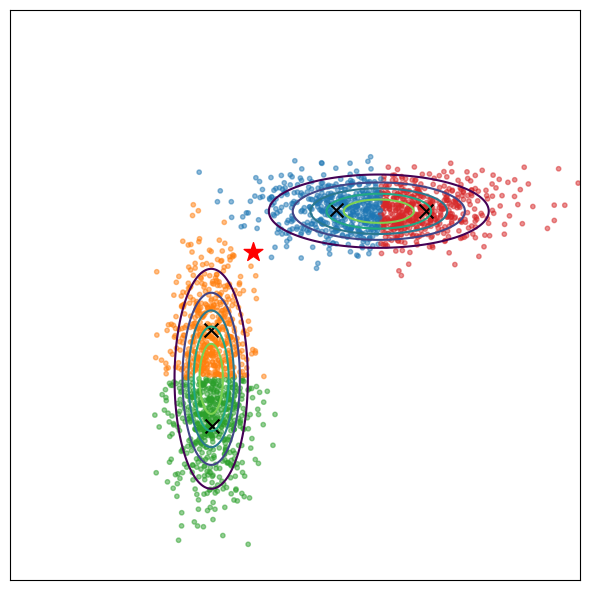

In [5]:
weights = torch.tensor(cluster_sizes) / samples.shape[0]

# set up linear system to solve for the star center

A = (weights[:, None, None] * inv_cluster_covariances).sum(dim=0)
b = (weights[:, None] * torch.einsum('nij,nj->ni', inv_cluster_covariances, cluster_centers)).sum(dim=0)

x_star = torch.linalg.solve(A, b)
# x_star = torch.tensor([-offset, offset])  # TODO: remove
# x_star = 1.1*torch.tensor([-offset, offset])  # TODO: remove

plt.figure(figsize=(6,6))
plt.contour(x_grid, y_grid, density, levels=new_levels)
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=plt.get_cmap('tab10')(cluster_labels), s=10)
plt.scatter(cluster_centers[:,0], cluster_centers[:,1], c='black', marker='x', s=100, label='Cluster Centers')
plt.scatter(x_star[0], x_star[1], c='red', marker='*', s=200, label='Star Center')
plt.xlim(-6.0 - offset, 6.0)
plt.ylim(-6.0, 6.0 + offset)
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.show()

## Construct StarFlow ##

In [6]:
multi_dist = MultiModalEllipsoidStarDistribution(covs=cluster_covariances, 
                                                 mus=[center - x_star for center in cluster_centers], 
                                                 p=0.95, 
                                                 trimmed=True, aggregation='softmax')
centered_multi_dist = RecenteredStarFlowDistribution(x_star, multi_dist)

In [7]:
# compute enclosing star
theta = torch.linspace(0, 2 * torch.pi, 100)
circle = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)
star = multi_dist.radial(circle).unsqueeze(1) * circle + x_star

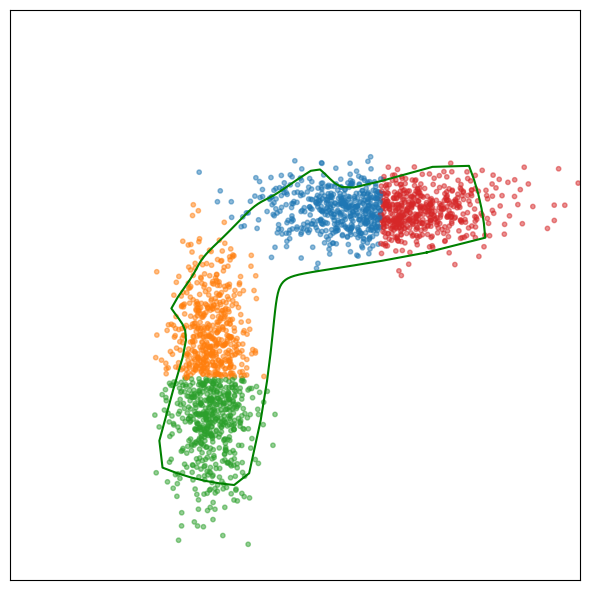

In [8]:
plt.figure(figsize=(6,6))
plt.plot(star[:,0], star[:,1], color='green', label="Enclosing Star Radial")
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=plt.get_cmap('tab10')(cluster_labels), s=10)
plt.xlim(-6.0 - offset, 6.0)
plt.ylim(-6.0, 6.0 + offset)
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.show()

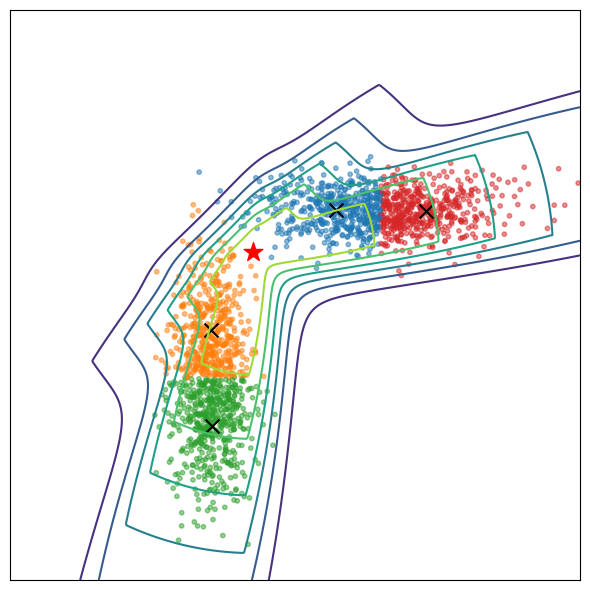

In [9]:
star_density = torch.exp(centered_multi_dist.log_prob(xy_grid.reshape(-1,2).float())).reshape(x_grid.shape)

plt.figure(figsize=(6,6))
plt.contour(x_grid, y_grid, star_density)
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, c=plt.get_cmap('tab10')(cluster_labels), s=10)
plt.scatter(cluster_centers[:,0], cluster_centers[:,1], c='black', marker='x', s=100, label='Cluster Centers')
plt.scatter(x_star[0], x_star[1], c='red', marker='*', s=200, label='Star Center')
plt.xlim(-6.0 - offset, 6.0)
plt.ylim(-6.0, 6.0 + offset)
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.show()

## Construct Pullback Manifold ##

In [10]:
phi = StarFlowVectorDiffeomorphism(2, centered_multi_dist, s=1.)
manifold = StandardPullbackVectorEuclidean(phi)

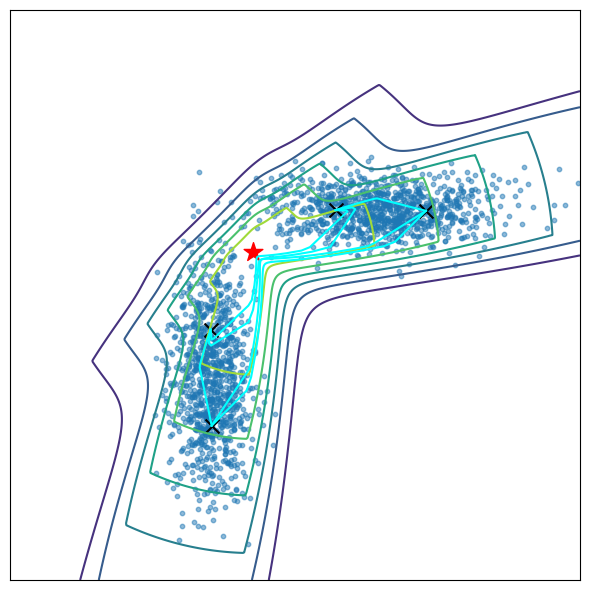

In [11]:
# compute geodesics between cluster centers
t = torch.linspace(0, 1, 50)

plt.figure(figsize=(6,6))
plt.contour(x_grid, y_grid, star_density)
plt.scatter(samples[:,0], samples[:,1], alpha=0.5, s=10)
plt.scatter(cluster_centers[:,0], cluster_centers[:,1], c='black', marker='x', s=100, label='Cluster Centers')
plt.scatter(x_star[0], x_star[1], c='red', marker='*', s=200, label='Star Center')

for i in range(n_clusters):
    for j in range(i+1, n_clusters):
        start = cluster_centers[i]
        end = cluster_centers[j]
        geodesic = manifold.geodesic(start[None,None], end[None,None], t)[0,0,0]
        plt.plot(geodesic[:,0], geodesic[:,1], c='cyan')

plt.xlim(-6.0 - offset, 6.0)
plt.ylim(-6.0, 6.0 + offset)
plt.xticks([])  # Remove x-axis ticks
plt.yticks([])  # Remove y-axis ticks
plt.gca().set_aspect('equal', adjustable='box')  # Ensure axes are equally spaced
plt.tight_layout()
plt.show()